# Dipole Antenna Mesh with PalaceToolkit

This notebook uses PalaceToolkit utilities with a robust workflow:
- build primitives
- fragment once for conformal topology
- define `Entity` objects from fragmented geometry
- run `run_entity_pipeline`, refine with `refine_near_surfaces`, then `generate_3d_mesh`
- visualize with `palacetoolkit.viz`


In [1]:
from pathlib import Path
import math
import gmsh

from palacetoolkit.geometry import xmin, xmax, ymin, ymax, zmin, zmax, extract_tag
from palacetoolkit.mesh import Entity, run_entity_pipeline, generate_3d_mesh, create_graded_mesh
from palacetoolkit.viz import view_mesh
from palacetoolkit.simulation import generate_palace_config_from_entities, run_palace
from palacetoolkit.verify_topology import verify, print_report, visualise_problems

In [2]:
wavelength = 4.0
arm_length = wavelength / 4
arm_radius = arm_length / 20
gap_size = arm_length / 50
outer_boundary_radius = 1.5 * wavelength
mesh_file = "dipole.msh"

In [3]:
if gmsh.isInitialized():
    gmsh.finalize()
gmsh.initialize()
gmsh.option.setNumber("General.Verbosity", 2)
gmsh.model.add("dipole_entity_pipeline")
occ = gmsh.model.occ

air = occ.addSphere(0, 0, 0, outer_boundary_radius)
top_arm = occ.addBox(-arm_radius, -arm_radius, gap_size / 2, 2 * arm_radius, 2 * arm_radius, arm_length)
bot_arm = occ.addBox(-arm_radius, -arm_radius, -gap_size / 2 - arm_length, 2 * arm_radius, 2 * arm_radius, arm_length)
port_sheet = occ.addRectangle(-arm_radius, -gap_size / 2, 0, 2 * arm_radius, gap_size)
occ.rotate([(2, port_sheet)], 0, 0, 0, 1, 0, 0, math.pi / 2)
occ.synchronize()

In [4]:
# Entity + boolean pipeline for named physical groups.
entities = [
    Entity("air", dim=3, mesh_order=2, btype="dielectric", tags=[air], loss_tan=0.0, eps_r=1.0, mu_r=1.0),
    Entity("top_arm", dim=3, mesh_order=1, btype="pec", tags=[top_arm]),
    Entity("bot_arm", dim=3, mesh_order=1, btype="pec", tags=[bot_arm]),
    Entity("port", dim=2, mesh_order=0, btype="lumped_port", tags=[port_sheet], R=50.0, direction="+Z", excitation=True),
]
pg_map = run_entity_pipeline(entities)

create_graded_mesh(
    wavelength,
    ppw_near=30,
    ppw_far=5,
    transition_distance=wavelength / 4,
    set_as_background=True
)

generate_3d_mesh(entities, output_file=mesh_file, optimize=True)
gmsh.finalize()
pg_map

  Physical group 'air' (dim=3): pg=1, tags=[1]
  Physical group 'top_arm' (dim=3): pg=2, tags=[2]
  Physical group 'bot_arm' (dim=3): pg=3, tags=[3]
  Physical group 'port' (dim=2): pg=4, tags=[14]
  Physical group 'air__None' (dim=2): pg=5, tags=[23]
  Physical group 'air__bot_arm' (dim=2): pg=6, tags=[19, 10, 21, 22, 11, 12, 20]
  Physical group 'air__top_arm' (dim=2): pg=7, tags=[15, 4, 7, 5, 17, 18, 16]
  global: 35 curves, SizeMin=0.1333
  ppw_near=30  ppw_far=5
  SizeMax=0.8000  transition=1.0000


Mesh saved to dipole.msh
  Nodes: 2621
  Elements: 14161


{'port': 4,
 'air__None': 5,
 'air__bot_arm': 6,
 'air__top_arm': 7,
 'air': 1,
 'top_arm': 2,
 'bot_arm': 3}

In [5]:
view_mesh(mesh_file, transparent_groups=["air__None"])

Loading mesh file: dipole.msh
Groups to render transparent: ['air__None']

Mesh loaded successfully with 2 cell blocks
Found 2938 triangles total
Physical group tags in mesh: {4: 'port', 5: 'air__None', 6: 'air__bot_arm', 7: 'air__top_arm'}


In [6]:
config_file: str = "dipole_antenna.json"
mesh_file = "dipole.msh"

# Frequency sweep centered around the dipole resonance.
# Each arm is lambda/4, so total dipole length is lambda/2 and
# the resonant frequency is approximately f0 = c / lambda.
c0 = 299_792_458.0
f0_hz = c0 / wavelength
f0_ghz = f0_hz / 1e9

freq_min: float = 0.75 * f0_ghz
freq_max: float = 1.25 * f0_ghz
freq_step: float = (freq_max-freq_min)/20
solver_order: int = 2

print(f"Estimated f0 = {f0_ghz:.6f} GHz")
print(f"Sweep: {freq_min:.6f} to {freq_max:.6f} GHz (step {freq_step:.6f} GHz)")

generate_palace_config_from_entities(entity_defs = [e.to_dict() for e in entities],
    pg_map = pg_map,
    mesh_file = mesh_file,
    output_file = config_file,
    freq_min = freq_min,
    freq_max = freq_max,
    freq_step = freq_step ,
    L0 = 1.0,
    solver_order = solver_order,
    absorbing_order = 2,
    farfield=True)

Estimated f0 = 0.074948 GHz
Sweep: 0.056211 to 0.093685 GHz (step 0.001874 GHz)
Palace config written to dipole_antenna.json


{'Problem': {'Type': 'Driven',
  'Verbose': 2,
  'Output': 'postpro/dipole_antenna'},
 'Model': {'Mesh': 'dipole.msh', 'L0': 1.0, 'Refinement': {}},
 'Domains': {'Materials': [{'Attributes': [1],
    'Permeability': 1.0,
    'Permittivity': 1.0,
    'LossTan': 0.0}]},
 'Boundaries': {'PEC': {'Attributes': [2, 3]},
  'Absorbing': {'Attributes': [5, 6, 7], 'Order': 2},
  'LumpedPort': [{'Index': 1,
    'Attributes': [4],
    'R': 50.0,
    'Excitation': True,
    'Direction': '+Z'}],
  'Postprocessing': {'FarField': {'Attributes': [5, 6, 7], 'NSample': 16000}}},
 'Solver': {'Order': 2,
  'Device': 'CPU',
  'Driven': {'MinFreq': 0.056211085875,
   'MaxFreq': 0.093685143125,
   'FreqStep': 0.0018737028625,
   'SaveStep': 5,
   'AdaptiveTol': 0.001},
  'Linear': {'Type': 'Default',
   'KSPType': 'GMRES',
   'Tol': 1e-08,
   'MaxIts': 500}}}

In [7]:
# Validate topology before launching Palace.
topology_result = verify(mesh_file, config_file)
topology_ok = print_report(topology_result)

if not topology_ok:
    print("Topology validation failed; opening mesh viewer in debug mode (problem faces highlighted).")
    visualise_problems(
        mesh_file,
        topology_result,
        transparent_groups=["air__None"],
        exclude_expected_periodic=False,
        only_nonmanifold=False,
    )
    raise RuntimeError("Mesh topology validation failed. Fix mesh/topology issues before running Palace.")



╔══════════════════════════════════════════════════════════════════════╗
║              Mesh Topological Consistency Report                    ║
╚══════════════════════════════════════════════════════════════════════╝

  Mesh file:             dipole.msh
  Vertices:              2,621
  Tetrahedra:            10,979
  Boundary triangles:    2,938
  Unique volume faces:   23,348
    interior (2 tets):   20,568
    skin     (1 tet):    2,780

  Physical groups (2-D):
    attr   1 = air
    attr   2 = top_arm
    attr   3 = bot_arm
    attr   4 = port
    attr   5 = air__None
    attr   6 = air__bot_arm
    attr   7 = air__top_arm

──────────────────────────────────────────────────────────────────────
  CHECK 1  —  Totality:  every boundary face ∈ volume faces
              (violation → MFEM abort: (r,c,f) = …)
──────────────────────────────────────────────────────────────────────
  ✅  Pass 1 (raw): all boundary faces found among volume faces.
  ⓘ   Pass 2 (periodic): skipped — no perio

In [8]:
run_palace(config_file=config_file, num_procs=16)

  Running: /home/martin/.cache/palacetoolkit/runtime/palace-cpu-v0.1.2/bin/palace -np 16 /home/martin/Desktop/PalaceToolkit/docs/examples/dipole_antenna.json
>> /usr/bin/mpirun -n 16 /home/martin/.cache/palacetoolkit/runtime/palace-cpu-v0.1.2/bin/palace-x86_64.bin /home/martin/Desktop/PalaceToolkit/docs/examples/dipole_antenna.json



_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (postpro/dipole_antenna)
Git changeset ID: v0.16.1-51-g4f2e2d97
Running with 16 MPI processes, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Removed 238 unmarked domain elements from the mesh

Characteristic length and time scales:
 Lc = 1.200e+01 m, tc = 4.003e+01 ns
Finished partitioning mesh into 16 subdomains

Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-5.990e+00, -5.997e+00, -6.000e+00) m
 (Xmax, Ymax, Zmax) = (+6.000e+00, +5.993e+00, +6.000e+00) m

Parallel Mesh Stats:

                minimum     average     maximum       total
 vertices           108         162         219        2600
 edges              794    


  Residual norms for GMRES solve
  0 (restart 0) KSP residual norm 2.303302e+01
  1 (restart 0) KSP residual norm 2.112687e+01


  2 (restart 0) KSP residual norm 2.110672e+01
  3 (restart 0) KSP residual norm 2.084100e+01
  4 (restart 0) KSP residual norm 1.529468e+01
  5 (restart 0) KSP residual norm 6.380694e+00
  6 (restart 0) KSP residual norm 5.264644e+00
  7 (restart 0) KSP residual norm 5.164768e+00
  8 (restart 0) KSP residual norm 5.005701e+00
  9 (restart 0) KSP residual norm 4.785968e+00


 10 (restart 0) KSP residual norm 4.695826e+00
 11 (restart 0) KSP residual norm 4.319290e+00
 12 (restart 0) KSP residual norm 4.254163e+00
 13 (restart 0) KSP residual norm 3.984606e+00
 14 (restart 0) KSP residual norm 3.865215e+00
 15 (restart 0) KSP residual norm 3.720438e+00
 16 (restart 0) KSP residual norm 3.661803e+00
 17 (restart 0) KSP residual norm 3.355238e+00


...


It 19/21: ω/2π = 8.994e-02 GHz (total elapsed time = 5.11e+01 s)

 Sol. ||E|| = 6.689244e+00
 Field energy E (6.466e-10 J) + H (9.546e-11 J) = 7.421e-10 J
 S[1][1] = +6.601e-01-3.115e-01i, |S[1][1]| = -2.735e+00, arg(S[1][1]) = -2.526e+01



It 20/21: ω/2π = 9.181e-02 GHz (total elapsed time = 5.24e+01 s)

 Sol. ||E|| = 6.640057e+00
 Field energy E (6.381e-10 J) + H (9.594e-11 J) = 7.341e-10 J
 S[1][1] = +6.549e-01-3.128e-01i, |S[1][1]| = -2.784e+00, arg(S[1][1]) = -2.553e+01



It 21/21: ω/2π = 9.369e-02 GHz (total elapsed time = 5.39e+01 s)

 Sol. ||E|| = 6.591736e+00
 Field energy E (6.298e-10 J) + H (9.639e-11 J) = 7.262e-10 J
 S[1][1] = +6.499e-01-3.140e-01i, |S[1][1]| = -2.832e+00, arg(S[1][1]) = -2.579e+01



 Wrote fields to disk (Paraview) at step 21



Completed 0 iterations of adaptive mesh refinement (AMR):
 Indicator norm = 3.729e-01, global unknowns = 75512
 Max. iterations = 0, tol. = 1.000e-02

Estimated peak per-rank memory usage is: Min. 114.7M, Max. 355.3M, Avg. 132.3M, Total 2.1G
Estimated peak per-node memory usage is: Min. 2.1G, Max. 2.1G, Avg. 2.1G, Total 2.1G

Elapsed Time Report (s)           Min.        Max.        Avg.
Initialization                   0.017       0.056       0.053
  Mesh Preprocessing             0.032       0.064       0.034
Operator Construction            0.087       7.141       6.698
Linear Solve                     4.662       4.690       4.675
  Setup                          1.020       1.020       1.020
  Preconditioner                25.817      25.979      25.938
  Coarse Solve                   2.825       2.965       2.860
PROM Construction                0.063       0.065       0.063
PROM Solve                       0.002       0.002       0.002
Estimation                       0.011   

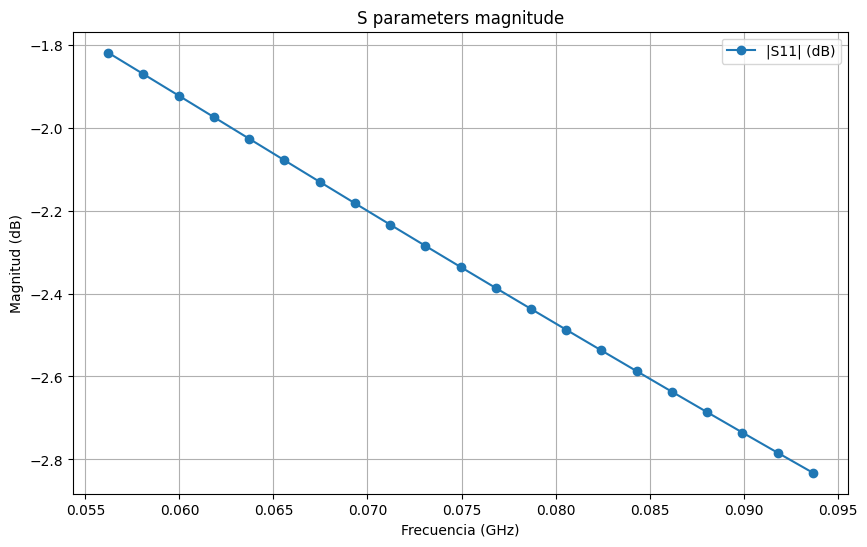

In [9]:
# S parameters. Return the frequency where the minimum is reached.
from pathlib import Path
from palacetoolkit.postpro import s_params

notebook_dir = Path().resolve()
postpro_dir = notebook_dir / "postpro" / "dipole_antenna"
    
f = s_params(str(postpro_dir / "port-S.csv"))